## Problem 5: Credit Risk Classification Using German Credit Data

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

**Load German Credit dataset**

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "Status_Checking_Account",
    "Duration_Months",
    "Credit_History",
    "Purpose",
    "Credit_Amount",
    "Savings_Account",
    "Employment_Since",
    "Installment_Rate",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Residence_Since",
    "Property",
    "Age",
    "Other_Installment_Plans",
    "Housing",
    "Existing_Credits",
    "Job",
    "People_Liable",
    "Telephone",
    "Foreign_Worker",
    "Credit_Risk"
]

data = pd.read_csv(url, sep=" ", header=None, names=columns)

data.head()

,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,People_Liable,Telephone,Foreign_Worker,Credit_Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
data.shape

(1000, 21)

In [4]:
data["Credit_Risk"].value_counts()

Credit_Risk
1    700
2    300
Name: count, dtype: int64

**Create binary target variable**

In [5]:
data["Bad_Risk"] = np.where(data["Credit_Risk"] == 2, 1, 0)

data[["Credit_Risk", "Bad_Risk"]].head()

,Credit_Risk,Bad_Risk
0,1,0
1,2,1
2,1,0
3,1,0
4,2,1


In [6]:
data["Bad_Risk"].value_counts()

Bad_Risk
0    700
1    300
Name: count, dtype: int64

**Separate X and y**

In [7]:
X = data.drop(columns=["Credit_Risk", "Bad_Risk"])

y = data["Bad_Risk"]

**Convert categorical variables into dummy variables**

In [8]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,People_Liable,Status_Checking_Account_A12,Status_Checking_Account_A13,Status_Checking_Account_A14,...,Property_A124,Other_Installment_Plans_A142,Other_Installment_Plans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_Worker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


In [9]:
X_encoded.shape

(1000, 48)

**Train - Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((700, 48), (300, 48))

**Fit Log. Reg. Model**

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [13]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000))
])

logit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](48,)","['Duration_Months','Credit_Amount','Installment_Rate',...,'Job_A174', 'Telephone_A192','Foreign_Worker_A202']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,48
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


**Predict Classes & Probabilities**

In [14]:
y_pred = logit_model.predict(X_test)

y_pred_prob = logit_model.predict_proba(X_test)[:, 1]

**Accuracy**

In [15]:
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.77

**Confusion Matrix**

In [16]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[185,  25],
       [ 44,  46]])

**Classification Report**

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       210
           1       0.65      0.51      0.57        90

    accuracy                           0.77       300
   macro avg       0.73      0.70      0.71       300
weighted avg       0.76      0.77      0.76       300



**ROC - AUC Score**

In [18]:
auc = roc_auc_score(y_test, y_pred_prob)

auc

0.7961375661375661

**ROC Curve**

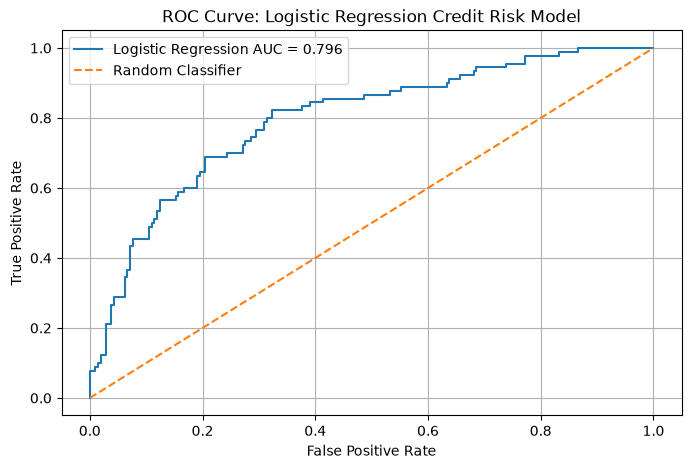

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression Credit Risk Model")
plt.legend()
plt.grid(True)

plt.show()

**Coefficient Table**

In [21]:
coefficient_table = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": logit_model.named_steps["logistic"].coef_[0]
})

coefficient_table["Abs_Coefficient"] = coefficient_table["Coefficient"].abs()

coefficient_table = coefficient_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coefficient_table.head(15)

,Feature,Coefficient,Abs_Coefficient
9,Status_Checking_Account_A14,-0.786192,0.786192
13,Credit_History_A34,-0.535851,0.535851
29,Employment_Since_A74,-0.473357,0.473357
26,Savings_Account_A65,-0.462414,0.462414
38,Property_A124,0.440451,0.440451
42,Housing_A153,-0.416289,0.416289
0,Duration_Months,0.365907,0.365907
2,Installment_Rate,0.362676,0.362676
32,Personal_Status_Sex_A93,-0.358975,0.358975
40,Other_Installment_Plans_A143,-0.356315,0.356315


### Interpretation of Logistic Regression Results

The Logistic Regression model was used to classify borrowers into good and bad credit risk categories using the German Credit dataset. The target variable was defined as 1 for bad credit risk and 0 for good credit risk.

The model achieved an accuracy of 0.77 on the test set, meaning that it correctly classified 77% of the observations. The ROC-AUC score was 0.796, indicating that the model has a reasonable ability to distinguish between good and bad credit risks.

The confusion matrix shows that the model correctly classified 185 good borrowers and 46 bad borrowers. However, it also misclassified 44 bad borrowers as good borrowers. This is an important limitation because, in credit risk, approving a bad borrower can be more costly than rejecting a good borrower.

The classification report shows that the model performs better for good borrowers than for bad borrowers. The recall for good borrowers is 0.88, while the recall for bad borrowers is only 0.51. This means that the model identifies most good borrowers correctly but catches only about 51% of actual bad borrowers.

The coefficient table shows which variables have the strongest influence on the predicted probability of bad credit risk. Since the target variable is bad credit risk, positive coefficients increase the probability of bad credit risk, while negative coefficients reduce it. For example, loan duration has a positive coefficient, suggesting that longer loan durations are associated with higher credit risk.

Overall, the Logistic Regression model provides a useful first classification model for credit risk. However, the relatively low recall for bad borrowers suggests that the model may need threshold adjustment or cost-sensitive evaluation before being used in a real lending context.

## END